In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pre-processing

In [2]:
files = os.listdir('res/accuracy')
column_names = ['epoch', 'step', 'plain_acc', 'enc_acc']

In [3]:
dfs = [pd.read_csv(f'res/accuracy/{file}', header=None, names=column_names).iloc[:400,2:] for file in files]
dfs[0]

,plain_acc,enc_acc
0,0.083333,0.083333
1,0.145833,0.145833
2,0.041667,0.041667
3,0.104167,0.104167
4,0.083333,0.083333
...,...,...
395,0.958333,0.958333
396,0.854167,0.854167
397,0.854167,0.854167
398,0.854167,0.854167


In [4]:
# Stack dataframes along a new axis and compute mean along that axis
mean_df = np.mean(dfs, axis=0)
mean_df = pd.DataFrame(mean_df, columns=column_names[2:])
mean_df

,plain_acc,enc_acc
0,0.076389,0.076389
1,0.069444,0.069444
2,0.062500,0.062500
3,0.097222,0.097222
4,0.111111,0.111111
...,...,...
395,0.916667,0.916667
396,0.861111,0.861111
397,0.881944,0.881944
398,0.847222,0.847222


In [5]:
# Stack dataframes along a new axis and compute std along that axis
std_df = np.std(dfs, axis=0)
std_df = pd.DataFrame(std_df, columns=column_names[2:])
std_df

,plain_acc,enc_acc
0,0.059738,0.059738
1,0.054681,0.054681
2,0.061332,0.061332
3,0.025984,0.025984
4,0.025984,0.025984
...,...,...
395,0.034021,0.034021
396,0.025984,0.025984
397,0.019642,0.019642
398,0.009821,0.009821


# Plot

In [6]:
params = {
   'font.size': 26,
   'axes.linewidth': 1.25,
   'axes.labelsize': 26,
   'legend.fontsize': 22,
   'xtick.labelsize': 26,
   'ytick.labelsize': 26,
}
plt.rcParams.update(params)

In [14]:
x_label = r'Iteration $t$'
y_label = 'Train accuracy %'
legend_labels = ['Plain', 'Encrypted']

In [15]:
from palettable.colorbrewer.qualitative import Set2_3
colors = Set2_3.mpl_colors

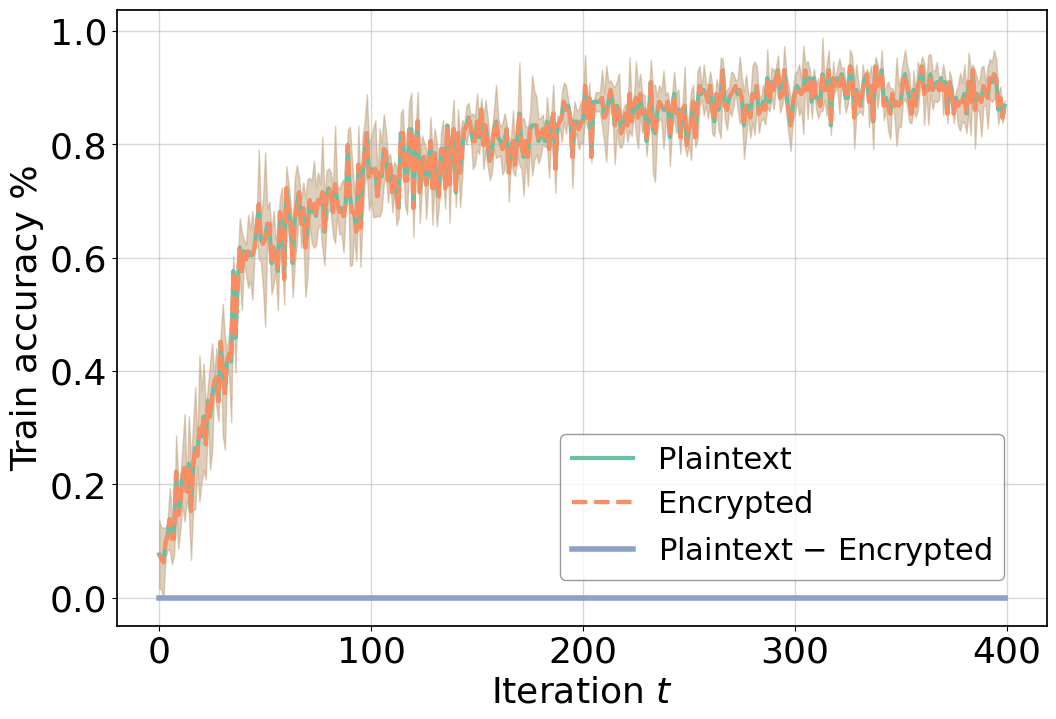

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

plain_mean = mean_df['plain_acc']
enc_mean = mean_df['enc_acc']
plain_std = std_df['plain_acc']
enc_std = std_df['enc_acc']

# Plot mean lines with labels for the legend
sns.lineplot(
    x=np.arange(0, len(plain_mean)), y=plain_mean,
    color=colors[0], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='-', label="Plaintext"
)
sns.lineplot(
    x=np.arange(0, len(enc_mean)), y=enc_mean,
    color=colors[1], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='--', label="Encrypted"
)

# Plot the difference between plain and encrypted (no scaling)
plain_enc_diff = plain_mean - enc_mean
sns.lineplot(
    x=np.arange(0, len(plain_enc_diff)), y=plain_enc_diff,
    color=colors[2], ax=ax, marker=None,
    linewidth=4, markersize=5, linestyle='-', label=r'Plaintext $-$ Encrypted'
)

# Plot standard deviation as shaded areas
ax.fill_between(np.arange(0, len(plain_mean)), plain_mean - plain_std, plain_mean + plain_std, color=colors[0], alpha=0.3)
ax.fill_between(np.arange(0, len(enc_mean)), enc_mean - enc_std, enc_mean + enc_std, color=colors[1], alpha=0.3)

ax.tick_params(axis='x')
ax.tick_params(axis='y')

# Create legend in the lower right outside the plot
legend = ax.legend(loc='lower right', bbox_to_anchor=(0.97, 0.05), frameon=True)
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [24]:
from pathlib import Path

fn = Path(f'out/acc_comparison.pdf')
fig.savefig(fn, bbox_inches='tight')